In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

os.makedirs("outputs/thresholds", exist_ok=True)

In [131]:
#load dataset
df = pd.read_csv("creditcard.csv")

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [132]:
#check class distribution
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [134]:
#split features and target
X = df.drop("Class", axis=1)
y = df["Class"]

In [135]:
#train-testsplit
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(227845, 30) (56962, 30)


In [136]:
#scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [137]:
#class weight calculation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [138]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled, y_train)

#randomforest classifier
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100)
rf.fit(X_train, y_train)

#xgboost
xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [139]:
#get probabilities
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
xgb_prob = xgb.predict_proba(X_test)[:, 1]

In [141]:
#Ensemble
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
xgb_prob = xgb.predict_proba(X_test)[:, 1]

In [142]:
#ensemble 

ensemble_prob = (
    0.2 * lr_prob +
    0.3 * rf_prob +
    0.5 * xgb_prob
)

ens_auc = roc_auc_score(y_test, ensemble_prob)

In [143]:
#threshold wise outputs
thresholds = [0.2, 0.3, 0.4, 0.5]

results = []

for t in thresholds:
    print(f"\n====== Threshold: {t} ======")

    y_pred = (ensemble_prob > t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-score: {f1}")

    results.append([t, precision, recall, f1])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix (Threshold={t})")
    plt.savefig(f"outputs/thresholds/conf_matrix_{t}.png")
    plt.close()

    #Precision vs Recall Graph
    plt.figure()
    plt.bar(["Precision", "Recall"], [precision, recall])
    plt.title(f"Precision vs Recall (Threshold={t})")
    plt.savefig(f"outputs/thresholds/pr_bar_{t}.png")
    plt.close()


====== Threshold: 0.2 ======
Precision: 0.4702702702702703
Recall: 0.8877551020408163
F1-score: 0.6148409893992933

====== Threshold: 0.3 ======
Precision: 0.8383838383838383
Recall: 0.8469387755102041
F1-score: 0.8426395939086294

====== Threshold: 0.4 ======
Precision: 0.9111111111111111
Recall: 0.8367346938775511
F1-score: 0.8723404255319149

====== Threshold: 0.5 ======
Precision: 0.9204545454545454
Recall: 0.826530612244898
F1-score: 0.8709677419354839


In [144]:
# Threshold comparison
df_results = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])
print(df_results)

df_results.to_csv("outputs/threshold_comparison.csv", index=False)

   Threshold  Precision    Recall        F1
0        0.2   0.470270  0.887755  0.614841
1        0.3   0.838384  0.846939  0.842640
2        0.4   0.911111  0.836735  0.872340
3        0.5   0.920455  0.826531  0.870968


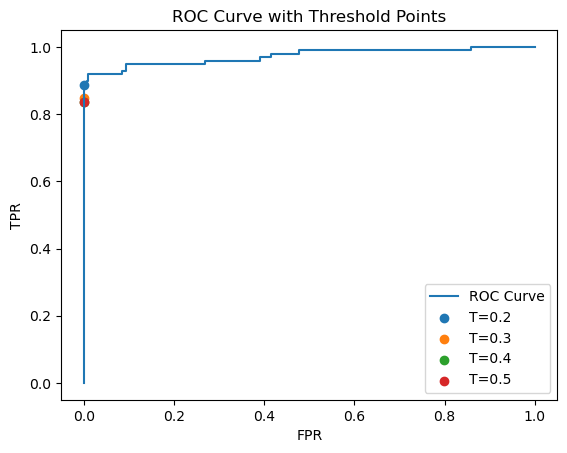

In [145]:
#ROC + threshold points
fpr, tpr, thresholds_roc = roc_curve(y_test, ensemble_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")

for t in thresholds:
    idx = (np.abs(thresholds_roc - t)).argmin()
    plt.scatter(fpr[idx], tpr[idx], label=f"T={t}")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve with Threshold Points")
plt.legend()

plt.savefig("outputs/roc_with_thresholds.png")
plt.show()

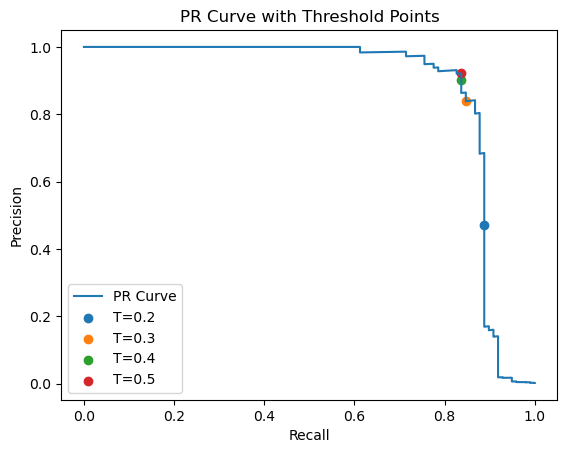

In [146]:
#Precision-Recall Curve +Threshold points
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, ensemble_prob)

plt.figure()
plt.plot(recall_vals, precision_vals, label="PR Curve")

for t in thresholds:
    idx = (np.abs(thresholds_pr - t)).argmin()
    plt.scatter(recall_vals[idx], precision_vals[idx], label=f"T={t}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve with Threshold Points")
plt.legend()

plt.savefig("outputs/pr_with_thresholds.png")
plt.show()

In [156]:
#Cost Analysis

import matplotlib.pyplot as plt

# Define costs (you can justify these in paper)
cost_FP = 100      # inconvenience cost
cost_FN = 10000    # fraud loss cost

cost_results = []

thresholds = df_results["Threshold"]

for t in thresholds:
    y_pred = (ensemble_prob > t).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    total_cost = (fp * cost_FP) + (fn * cost_FN)

    cost_results.append([t, fp, fn, total_cost])

# Convert to DataFrame
cost_df = pd.DataFrame(cost_results, columns=["Threshold", "FP", "FN", "Total_Cost"])

print(cost_df)

# Save to CSV
cost_df.to_csv("outputs/cost_analysis.csv", index=False)

   Threshold  FP  FN  Total_Cost
0        0.2  98  11      119800
1        0.3  16  15      151600
2        0.4   8  16      160800
3        0.5   7  17      170700


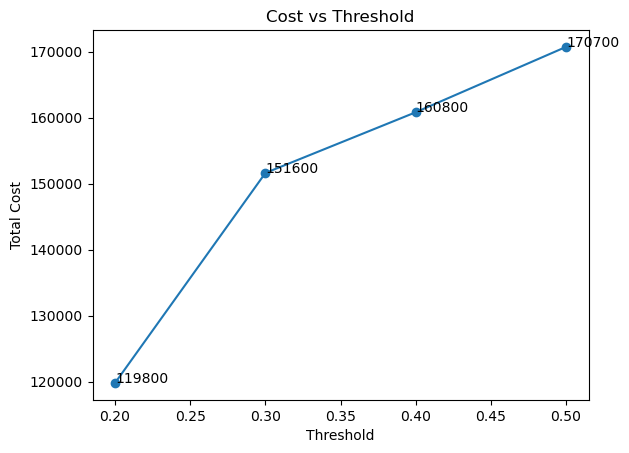

In [157]:
#cost v/s threshold graph
plt.figure()
plt.plot(cost_df["Threshold"], cost_df["Total_Cost"], marker='o')

plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Cost vs Threshold")

for i, txt in enumerate(cost_df["Total_Cost"]):
    plt.annotate(txt, (cost_df["Threshold"][i], cost_df["Total_Cost"][i]))

plt.savefig("outputs/cost_vs_threshold.png")
plt.show()


In [158]:
#higlight best threshold
best_row = cost_df.loc[cost_df["Total_Cost"].idxmin()]

print("\nBest Threshold Based on Cost:")
print(best_row)


Best Threshold Based on Cost:
Threshold          0.2
FP                98.0
FN                11.0
Total_Cost    119800.0
Name: 0, dtype: float64


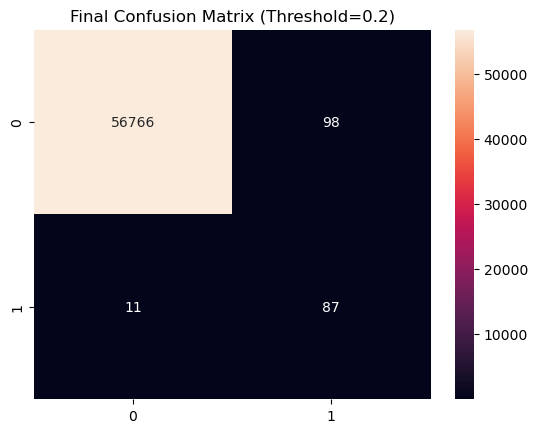

In [153]:
#Confusion Matrix
best_threshold = best_row["Threshold"]
final_pred = (ensemble_prob > best_threshold).astype(int)

cm = confusion_matrix(y_test, final_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Final Confusion Matrix (Threshold={best_threshold})")
plt.savefig("outputs/final_conf_matrix.png")
plt.show()

In [160]:
#save predictions
results_df = pd.DataFrame({
    "Actual": y_test,
    "Probability": ensemble_prob,
    "Prediction": final_pred
})

results_df.to_csv("outputs/predictions.csv", index=False)

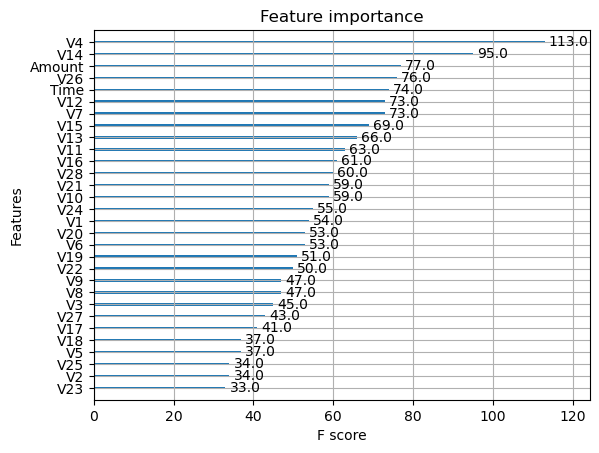

In [161]:
#Feature Importance
from xgboost import plot_importance

plot_importance(xgb)
plt.savefig("outputs/feature_importance.png")
plt.show()

In [162]:
#Model Comparison
# --- Comparison ---
comparison = pd.DataFrame({
    "Model": ["LR", "RF", "XGB", "ENSEMBLE"],
    "ROC_AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        ens_auc
    ]
})
comparison.to_csv("outputs/model_comparison.csv", index=False)
print(comparison)

      Model   ROC_AUC
0        LR  0.972083
1        RF  0.958074
2       XGB  0.974323
3  ENSEMBLE  0.972342


In [163]:
#Save Predictions
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": ensemble_pred,
    "Probability": ensemble_prob
})
pred_df.to_csv("outputs/predictions.csv", index=False)

In [164]:
#Save Models
import os, joblib, json
os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

joblib.dump(lr, "models/lr.pkl")
joblib.dump(rf, "models/rf.pkl")
joblib.dump(xgb, "models/xgb.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [165]:
#Metrics + Logs
with open("outputs/metrics.json", "w") as f:
    json.dump({"roc_auc": float(ens_auc)}, f)

with open("logs/training.log", "w") as f:
    f.write(f"Training complete\nROC-AUC: {ens_auc}")

print("ALL DONE")

ALL DONE
